In [1]:
import os, glob, numpy as np
import matplotlib.pyplot as plt

In [2]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id="raphael-blanchard/TartanIMU",
    repo_type="dataset",
    local_dir="hf_tartanimu",
)
print("Downloaded to:", local_dir)

ModuleNotFoundError: No module named 'huggingface_hub'

In [3]:
!pip install -U huggingface_hub

     |████████████████████████████████| 566 kB 246 kB/s eta 0:00:01
     |████████████████████████████████| 806 kB 5.7 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 5.4 MB/s  eta 0:00:01
     |████████████████████████████████| 3.3 MB 47.5 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 118 kB/s  eta 0:00:01
     |████████████████████████████████| 71 kB 8.7 MB/s  eta 0:00:01
     |████████████████████████████████| 126 kB 34.6 MB/s eta 0:00:01
     |████████████████████████████████| 152 kB 25.5 MB/s eta 0:00:01
     |████████████████████████████████| 147 kB 42.6 MB/s eta 0:00:01


In [1]:
import huggingface_hub
print(huggingface_hub.__version__)

0.36.2


In [2]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id="raphael-blanchard/TartanIMU",
    repo_type="dataset",
    local_dir="hf_tartanimu",
)
print("Downloaded to:", local_dir)

/home/efepc/my_ML_projects/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 24 files: 100%|████████████████████████| 24/24 [00:11<00:00,  2.03it/s]

Downloaded to: /home/efepc/my_ML_projects/OGAM/TartanIMU-Stage-1-Reproducing/notebooks/hf_tartanimu


In [3]:
import os, glob

root = "hf_tartanimu"
all_files = glob.glob(os.path.join(root, "**"), recursive=True)
files = [p for p in all_files if os.path.isfile(p)]
print("num files:", len(files))
for p in files:
    print(p)

num files: 22
hf_tartanimu/README.md
hf_tartanimu/data/samples/human/test/pretrain_1.npz
hf_tartanimu/data/samples/human/test/pretrain_3.npz
hf_tartanimu/data/samples/human/test/pretrain_4.npz
hf_tartanimu/data/samples/human/test/pretrain_2.npz
hf_tartanimu/data/samples/drone/test/pretrain_1.npz
hf_tartanimu/data/samples/drone/test/pretrain_3.npz
hf_tartanimu/data/samples/drone/test/pretrain_4.npz
hf_tartanimu/data/samples/drone/test/pretrain_2.npz
hf_tartanimu/data/samples/car/test/tartandrive_adapt_0200.npz
hf_tartanimu/data/samples/car/test/pretrain_1.npz
hf_tartanimu/data/samples/car/test/pretrain_3.npz
hf_tartanimu/data/samples/car/test/pretrain_4.npz
hf_tartanimu/data/samples/car/test/tartandrive_adapt_all.npz
hf_tartanimu/data/samples/car/test/pretrain_2.npz
hf_tartanimu/data/samples/dog/test/pretrain_1.npz
hf_tartanimu/data/samples/dog/test/pretrain_3.npz
hf_tartanimu/data/samples/dog/test/pretrain_4.npz
hf_tartanimu/data/samples/dog/test/pretrain_2.npz
hf_tartanimu/checkpoints

In [4]:
import os, glob
cands = glob.glob(os.path.join("hf_tartanimu", "**", "*traj6*.npz"), recursive=True)
print("traj6 npz:", len(cands))
print("\n".join(cands))

traj6 npz: 0



In [5]:
import numpy as np

p = "hf_tartanimu/data/samples/human/test/pretrain_1.npz"
z = np.load(p)
print("keys:", z.files)
for k in z.files:
    a = z[k]
    print(k, a.shape, a.dtype)

keys: ['retargetted_ts', 'retargetted_imu', 'retargetted_pos', 'retargetted_quat']
retargetted_ts (24190, 1) float64
retargetted_imu (24190, 6) float64
retargetted_pos (24190, 3) float64
retargetted_quat (24190, 4) float64


In [7]:
import numpy as np

z = np.load("hf_tartanimu/data/samples/human/test/pretrain_1.npz")

ts   = z["retargetted_ts"].flatten()
pos  = z["retargetted_pos"]
quat = z["retargetted_quat"][:, [3, 0, 1, 2]].astype(np.float64) # xyzw -> wxyz

dt = np.clip(np.diff(ts), 1e-6, None)[:, None]

# Vektörize Hız Hesaplama
vel = np.diff(pos, axis=0) / dt

# Vektörize Kuaterniyon Çarpımı (dq = q_conj(q_n) * q_n+1)
q_conj = q_curr.copy()
q_conj[:,1:] *= -1  # conj: (w, -x, -y, -z)
# dq = q_conj ⊗ q_next (Hamilton product)

dq = np.stack([
    q_curr[:,0]*q_next[:,0] + np.sum(q_curr[:,1:]*q_next[:,1:], axis=1), # w
    q_curr[:,0]*q_next[:,1] - q_curr[:,1]*q_next[:,0] - q_curr[:,2]*q_next[:,3] + q_curr[:,3]*q_next[:,2], # x
    q_curr[:,0]*q_next[:,2] + q_curr[:,1]*q_next[:,3] - q_curr[:,2]*q_next[:,0] - q_curr[:,3]*q_next[:,1], # y
    q_curr[:,0]*q_next[:,3] - q_curr[:,1]*q_next[:,2] + q_curr[:,2]*q_next[:,1] - q_curr[:,3]*q_next[:,0]  # z
], axis=1)

# Vektörize RPY (Euler) Dönüşümü
w, x, y, z = dq.T
roll  = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
pitch = np.arcsin(np.clip(2*(w*y - z*x), -1.0, 1.0))
yaw   = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))

rpy_rate = np.stack([roll, pitch, yaw], axis=1) / dt

state6 = np.concatenate([vel, rpy_rate], axis=1)
print(f"state6: {state6.shape}\nvx range: {state6[:,0].min()} {state6[:,0].max()}")

state6: (24189, 6)
vx range: -1.1735277226496899 1.0963145069915459


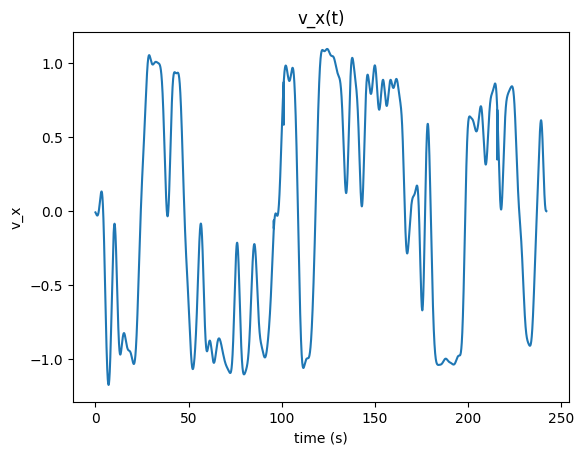

In [8]:
import matplotlib.pyplot as plt

t = ts[1:] - ts[0]

plt.figure()
plt.plot(t, state6[:,0])
plt.title("v_x(t)")
plt.xlabel("time (s)")
plt.ylabel("v_x")
plt.show()

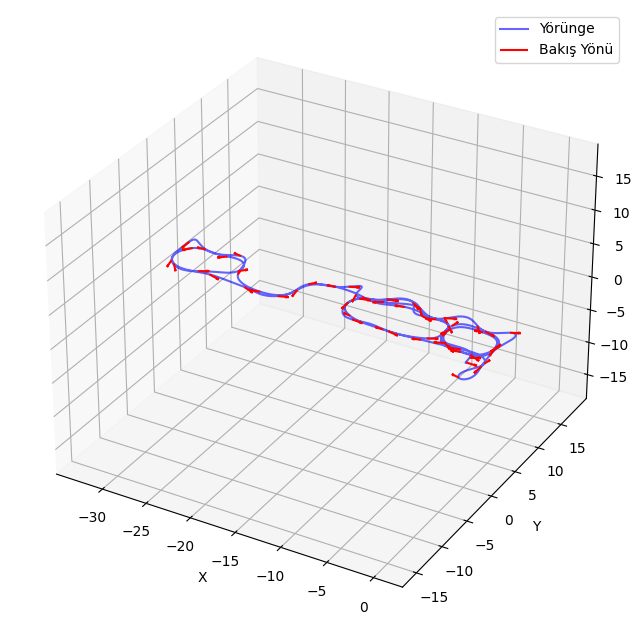

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Yükleme ve Hazırlık ----
z = np.load("hf_tartanimu/data/samples/human/test/pretrain_1.npz")
P = z["retargetted_pos"].astype(np.float64)
P -= P[0]  # Origin'e çek

# xyzw -> wxyz (Vektörize ayırma)
q = z["retargetted_quat"].astype(np.float64)
w, x, y, z = q[:, 3], q[:, 0], q[:, 1], q[:, 2]

# ---- Vektörize Bakış Yönü (Look Direction) Hesaplama ----
# f_body = [1, 0, 0] varsayımıyla R @ [1, 0, 0] işleminin sadeleşmiş hali:
# R matrisinin ilk sütunu doğrudan ileri bakış (x-axis) yönünü verir.
fx = 1 - 2 * (y**2 + z**2)
fy = 2 * (x*y + w*z)
fz = 2 * (x*z - w*y)
F = np.stack([fx, fy, fz], axis=1)

# ---- Görselleştirme ----
stride = 400
idx = np.arange(0, len(P), stride)
L = 0.03 * np.linalg.norm(P.max(axis=0) - P.min(axis=0))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Trajectory ve Oklar (Quiver)
ax.plot(P[:, 0], P[:, 1], P[:, 2], 'b-', alpha=0.6, label="Yörünge")
ax.quiver(P[idx, 0], P[idx, 1], P[idx, 2], 
          F[idx, 0], F[idx, 1], F[idx, 2], 
          length=L, color='red', normalize=True, label="Bakış Yönü")

# Eksen Eşitleme (Kısa yol)
max_range = np.ptp(P, axis=0).max() / 2.0
mid = (P.max(axis=0) + P.min(axis=0)) / 2.0
ax.set_xlim(mid[0]-max_range, mid[0]+max_range)
ax.set_ylim(mid[1]-max_range, mid[1]+max_range)
ax.set_zlim(mid[2]-max_range, mid[2]+max_range)

ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.legend()
plt.show()